# Phase 1: Task 4: Statistics Foundations

## Summary
This notebook demonstrates descriptive statistics, distributions, sampling, correlation, and probability using the DataTrove sales dataset.

In [7]:
#Importing Libraries
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for better-looking statistical plots
import seaborn as sns

In [8]:
# Load the dataset from the dataset folder
# The "../" means go one folder up from the current notebook location
df = pd.read_csv("../dataset/datatrove_sales_2024.csv")

In [9]:
# Display the first 5 rows of the dataset
# To confirm the data loaded correctly
df.head()

,order_id,order_date,city,category,product_name,quantity,unit_price,discount_pct,total_amount,customer_id,return_flag,sales_channel,payment_method
0,DT-20240069,2024-01-01,Ibadan,Home & Garden,Table Lamp,1,24.03,0,24.03,CUST-0139,N,Online,Cash
1,DT-20240027,2024-01-02,Abuja,Home & Garden,Table Lamp,4,26.68,0,106.72,CUST-0034,N,Online,Card
2,DT-20240073,2024-01-02,Abuja,Beauty & Health,Face Moisturiser,4,18.72,0,74.88,CUST-0077,N,In-Store,Bank Transfer
3,DT-20240215,2024-01-03,Enugu,Electronics,USB-C Hub,4,25.03,15,85.10,CUST-0053,N,In-Store,Bank Transfer
4,DT-20240362,2024-01-04,Port Harcourt,Electronics,Wireless Headphones,5,49.33,0,246.65,CUST-0031,N,Online,Cash


## 2. Descriptive Statistics: total_amount

### 2a. Mean, Median, Mode

This section is to compute measures of central tendency for total_amount.
Mean gives the average, median gives the middle value, and mode is better suited for discrete data such as quantity.

In [16]:
# Calculate the mean (average) of total_amount
mean_val = df["total_amount"].mean()

# Calculate the median (middle value when sorted)
median_val = df["total_amount"].median()

# Calculate the mode of a discrete column (quantity)
# Mode is more meaningful for discrete data because values repeat
mode_quantity = df["quantity"].mode()

# Display results
print("Mean of total_amount:", mean_val)
print("Median of total_amount:", median_val)
print("Mode of quantity:", mode_quantity.values)

Mean of total_amount: 95.17052
Median of total_amount: 62.025000000000006
Mode of quantity: [1]


#### Explanation
The mean represents the average order value but can be affected by very large orders.
The median shows the middle value and is more robust to extreme values.
The mode is useful for discrete variables like quantity because repeated values exist.

### 2b. Range, Variance, Standard Deviation, IQR

These statistics describe how spread out the total_amount values are.

In [15]:
# Calculate the range (difference between max and min)
range_val = df["total_amount"].max() - df["total_amount"].min()

# Calculate variance (average squared deviation from the mean)
variance_val = df["total_amount"].var()

# Calculate standard deviation (square root of variance)
std_val = df["total_amount"].std()

# Calculate quartiles
Q1 = df["total_amount"].quantile(0.25)  # 25th percentile
Q3 = df["total_amount"].quantile(0.75)  # 75th percentile

# Calculate interquartile range (IQR)
IQR = Q3 - Q1

# Display outputs
print("Range:", range_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_val)
print("Interquartile Range (IQR):", IQR)

Range: 652.8100000000001
Variance: 10133.682054638877
Standard Deviation: 100.66619121948976
Interquartile Range (IQR): 89.44749999999999


#### Explanation
The range shows the total spread of values.
Variance and standard deviation measure how dispersed the data is.
The IQR (Inter-quarile range) focuses on the middle 50% of the data and is less affected by outliers.

### 2c. Skewness and Kurtosis

These measures describe the shape of the distribution of total_amount.

In [17]:
# Calculate skewness (measure of asymmetry)
skewness = df["total_amount"].skew()

# Calculate kurtosis (measure of tail heaviness)
kurtosis = df["total_amount"].kurt()

# Display results
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 2.4792294512170727
Kurtosis: 7.384030236489721


#### Explanation
A positive skew means the distribution has a long right tail, indicating some very large orders.
A negative skew would indicate a long left tail.
Kurtosis shows how heavy or light the tails are compared to a normal distribution.

### 2d. Why Median Can Be More Useful Than Mean

Revenue data often contains extreme values (very large orders).
These outliers can pull the mean upward, making it less representative of a typical order.

The median is more reliable because it is not affected by extreme values,
so it better reflects what a typical customer spends.

## 3. Distributions

### 3a. Distribution of Total Amount

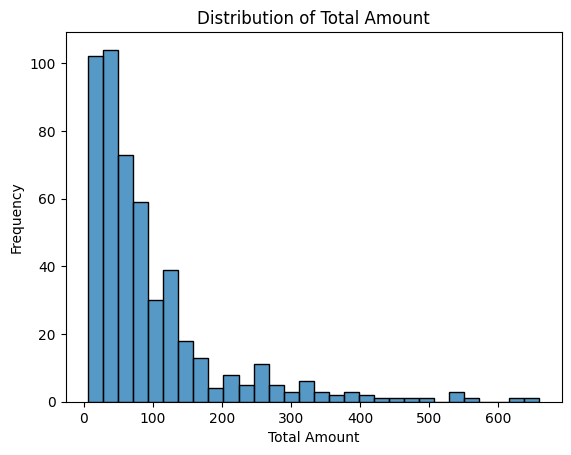

In [18]:
# Plot histogram of total_amount to understand its distribution
plt.figure()

sns.histplot(df["total_amount"], bins=30)

# Add title and labels
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

#### Explanation
The total amount distribution is right-skewed, with most values concentrated on the lower end and a long tail to the right.

### 3b. Distribution of Unit Price

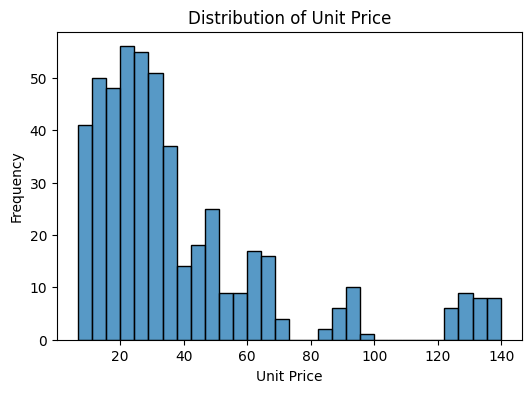

In [19]:
# Histogram for unit_price

plt.figure(figsize=(6, 4))

sns.histplot(df["unit_price"], bins=30)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

#### Explanation
The unit price distribution is positively skewed (right-skewed), with most unit prices concentrated at lower values and a long tail extending towards higher prices.

### 3c. Distribution of Quantity

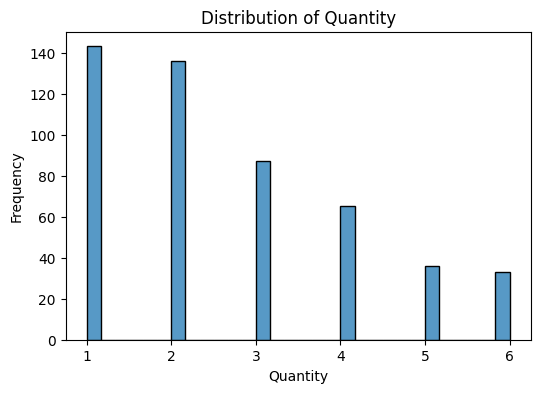

In [21]:
# Histogram for quantity

plt.figure(figsize=(6, 4))

sns.histplot(df["quantity"], bins=30)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

#### Explanation
The distribution is right-skewed, with most values concentrated at lower quantities and frequencies decreasing as quantity increases.

## 4. Sampling

 Take 50 random samples of size 30 from total_amount (use Series.sample(30, replace=True, random_state=...) so the work is reproducible), compute the mean of each sample, and plot the distribution of those 50 means. Then compare it to a histogram of the raw total_amount and explain what the Central Limit Theorem tells us: why the distribution of sample means is tighter (smaller spread) and looks more bell-shaped than the original data, even though the raw data is skewed.

In [23]:
# Create an empty list to store sample means
sample_means = []

# Take 50 samples of size 30
for i in range(50):
    
    # Draw sample
    sample = df["total_amount"].sample(n=30, replace=True, random_state=i)
    
    # Compute mean
    mean_value = sample.mean()
    
    # Store result
    sample_means.append(mean_value)

# Convert to pandas Series
sample_means = pd.Series(sample_means)

# SHOW OUTPUT
print("First 5 sample means:")
print(sample_means.head())

First 5 sample means:
0    104.729333
1    103.396333
2     99.926667
3     96.981333
4    108.839333
dtype: float64


### Plot Comparism

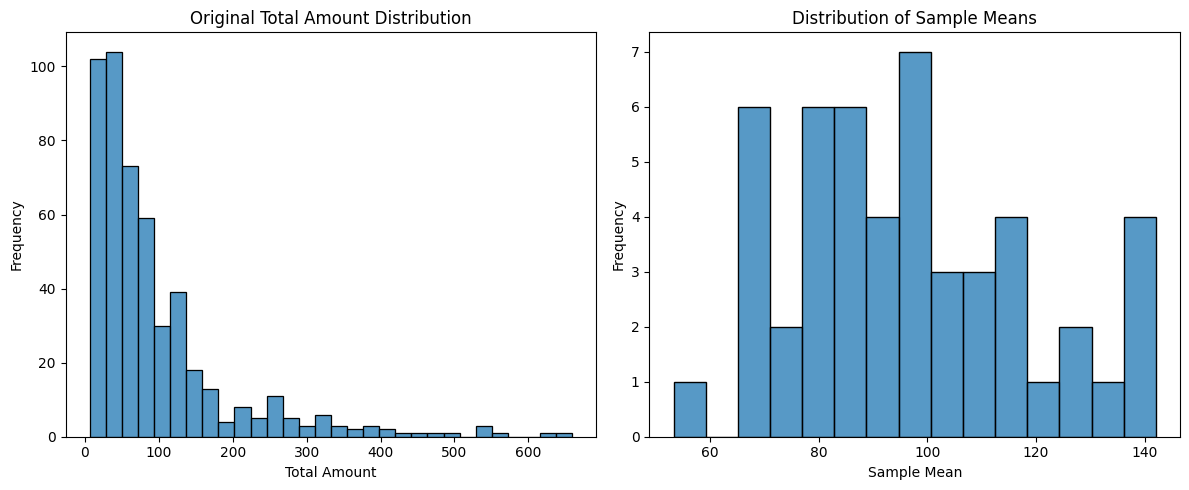

In [25]:
## Plot original data vs sample means

plt.figure(figsize=(12, 5))

# Plot original distribution
plt.subplot(1, 2, 1)
sns.histplot(df["total_amount"], bins=30)
plt.title("Original Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

# Plot sample means distribution
plt.subplot(1, 2, 2)
sns.histplot(sample_means, bins=15)
plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Explanation
The distribution of sample means is more bell-shaped and has a smaller spread compared to the original data.

This is explained by the Central Limit Theorem, which states that the distribution of sample means tends to become approximately normal as the sample size increases, even if the original data is skewed.

The spread is smaller because averaging reduces the effect of extreme values.

## 5. Correlation
Compute the Pearson correlation between quantity and total_amount. Plot a scatter. Explain in your own words the difference between correlation and causation.


In [26]:
# Compute Pearson correlation
correlation = df["quantity"].corr(df["total_amount"])

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.5295348106499038


### Plot a Scatterplot

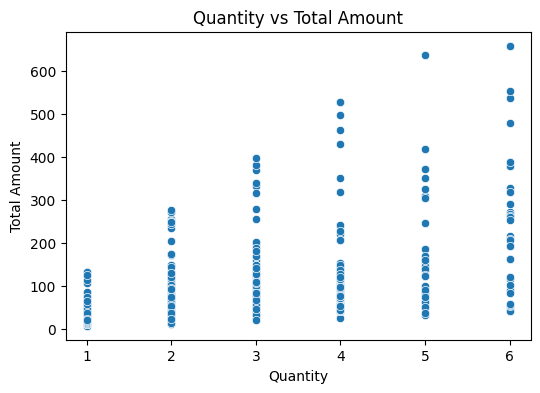

In [27]:
plt.figure(figsize=(6, 4))

# Scatter plot
sns.scatterplot(x=df["quantity"], y=df["total_amount"])

plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")

plt.show()

#### Difference Between Correlation and Causation
Correlation measures how strongly two variables move together.

Causation means that one variable directly causes a change in another.

Even if two variables are strongly correlated, it does not mean that one causes the other.

## 6. Probability
Using the dataset, answer:
What is the probability a random order is from Lagos?
Given an order is from Lagos, what is the probability it is in the Electronics category? (Conditional probability.)
Show your working both as a count-based fraction and using pandas boolean indexing.

In [29]:
# 6a. Probability of Lagos

# Total number of orders
total_orders = len(df)

# Number of orders from Lagos
lagos_orders = len(df[df["city"] == "Lagos"])

# Probability calculation
prob_lagos = lagos_orders / total_orders

print("P(Lagos):", prob_lagos)

P(Lagos): 0.226


In [31]:
# 6b. Conditional Probability

# Orders that are both Lagos AND Electronics
lagos_electronics = len(
    df[(df["city"] == "Lagos") & (df["category"] == "Electronics")]
)

# Conditional probability
prob_conditional = lagos_electronics / lagos_orders

print("P(Electronics | Lagos):", prob_conditional)

P(Electronics | Lagos): 0.26548672566371684


#### 6c. Working Explanation
P(Lagos) = (Number of Lagos orders) / (Total number of orders)

P(Electronics | Lagos) = (Number of Lagos orders in Electronics) / (Total Lagos orders)

These were computed using pandas boolean indexing.

## 7. Written Reflection
#### In ≤ 200 words: which statistic in this notebook would you most trust if a stakeholder asked "how big is a typical DataTrove order?", and why?

The statistic I would most trust to describe a typical DataTrove order is the median total amount.

This is because the distribution of total_amount is right-skewed, meaning that a small number of very large orders pull the mean upward. As a result, the mean does not accurately reflect the typical order size.

The median represents the middle value of the dataset and is not affected by extreme values or outliers. This makes it a more reliable measure of central tendency for skewed data.

Therefore, the median provides a more realistic estimate of what a typical customer spends.